In [2]:
from made.data_pipeline.data.datacomp_handler import decode_webdataset, get_next_batch
from made.data_pipeline.utils import collect_tar_files

In [78]:
dataset = iter(decode_webdataset(
    collect_tar_files("/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data"), # 20220 samples read in 1m 10s
    get_images=True,
    get_captions=True,
    batch_size=2000
))

Found 4 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data


In [79]:

from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
processor = AutoProcessor.from_pretrained("leobaro/DFN-public")
model = AutoModelForZeroShotImageClassification.from_pretrained("leobaro/DFN-public").eval().to("cuda")

In [80]:
uid_score = {}
i_dataset = iter(dataset)
while True:
    batch = get_next_batch(i_dataset)
    if batch is None:
        break
    uids, images, captions = batch
    print("New batch!")
    for uid, img, txt in zip(uids, images, captions):
        try:
            inputs = processor(text=[txt], images=[img], return_tensors="pt", padding=True, truncation=True, max_length=77).to("cuda")
        except Exception as e:
            print(e)
            continue
        outputs = model(**inputs)
        uid_score[uid] = outputs.logits_per_image.item()


New batch!


The channel dimension is ambiguous. Got image shape (3, 5, 3). Assuming channels are the first dimension.


New batch!


The channel dimension is ambiguous. Got image shape (1, 1, 3). Assuming channels are the first dimension.


mean must have 1 elements if it is an iterable, got 3


...

mean must have 1 elements if it is an iterable, got 3
New batch!
New batch!


The channel dimension is ambiguous. Got image shape (1, 1, 3). Assuming channels are the first dimension.


mean must have 1 elements if it is an iterable, got 3
New batch!
New batch!
New batch!


The channel dimension is ambiguous. Got image shape (3, 56, 3). Assuming channels are the first dimension.


New batch!


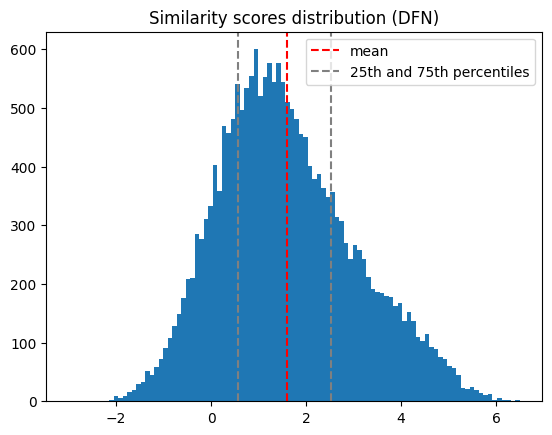

In [81]:
import matplotlib.pyplot as plt
import numpy as np
plt.title("Similarity scores distribution (DFN)")
sim_scores = list(uid_score.values())
plt.hist(sim_scores, bins=100)
plt.axvline(x=np.mean(sim_scores), color='red', linestyle='--', label='mean')
plt.axvline(x=np.percentile(sim_scores, 25), color='grey', linestyle='--', label='25th and 75th percentiles')
plt.axvline(x=np.percentile(sim_scores, 75), color='grey', linestyle='--')
plt.legend()
plt.show()


In [90]:
p_75 = np.percentile(sim_scores, 75)
p_25 = np.percentile(sim_scores, 25)

In [92]:
uids_gt_75_perc = [uid for uid, score in uid_score.items() if score > p_75]
uids_lt_25_perc = [uid for uid, score in uid_score.items() if score < p_25]
uids_between_25_and_75_perc = [uid for uid, score in uid_score.items() if score > p_25 and score < p_75]

In [95]:
# random sample 10 uids without replacement from each list
import random
uids_gt_75_perc = random.sample(uids_gt_75_perc, 10)
uids_lt_25_perc = random.sample(uids_lt_25_perc, 10)
uids_between_25_and_75_perc = random.sample(uids_between_25_and_75_perc, 10)


In [96]:
def display_uids(uid_list):
    dataset = iter(decode_webdataset(
        collect_tar_files("/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data"), # 20220 samples read in 1m 10s
        get_images=True,
        get_captions=True,
        batch_size=2000,
        valid_uids=uid_list
    ))
    uids, images, captions = get_next_batch(iter(dataset))
    for uid, img, txt in zip(uids, images, captions):
        print(uid)
        print(txt)
        display(img)




## Greater than 75 percentile

Found 4 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data
ad55359a9afe6226fe9ba4d639489448
Villa �eljka - Trogir Chorv�tsko


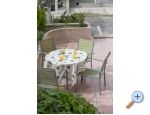

ccdd025fd13e3c0303b47cd330c2133a
Corn-oil-Teosinthe


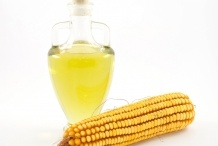

e1dddecd9fb78f8c75685efe15b27c5d
Making My Own Mulch And Rock Garden Flower Bed


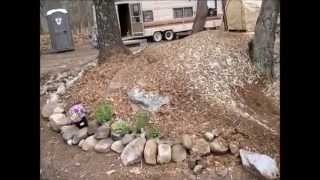

5a6c97a8f11c2be5bbdf16243ddabf9d
2018 CITROEN BERLINGO MULTISPACE 1.6 BlueHDi 100 Flair 5dr ETG6


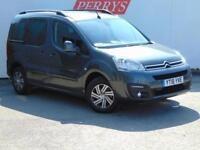

c53ed64468db790c7f405f33d783f9b1
Dubai 3x3m Gazebo Mocha top


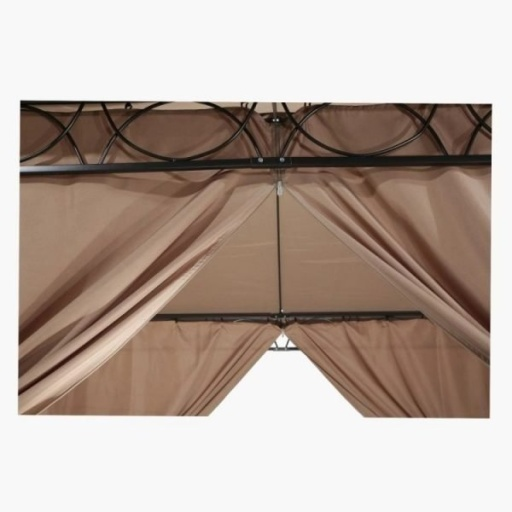

254908668bc3e9d7be660170696965c6
Quince Invitations, Box Wedding Invitations, Quinceanera Invitations, Wedding Boxes, Wedding Menu, Butterfly Baby Shower, Butterfly Party, Butterfly Birthday


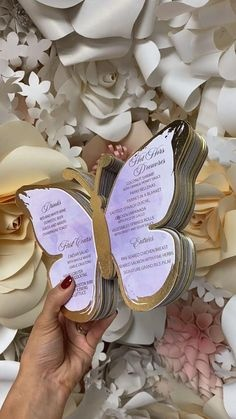

01a706c43138f3ade66935ef5dd3d2b1
Bright green and yellow stir fried zucchini are piled in a while bowl, and garnished in sesame seeds.


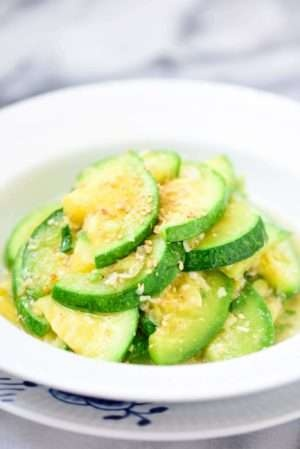

317b2aee74c4dca3be29a51d0c885b22
Roundshotus  Marvellous Effortless Invoicing  Invoicely With Inspiring Customize Your Invoices With Captivating Free Invoice Pdf Also Aynax Free Invoice In Addition Johnson Controls Invoicing And Sending Paypal Invoice As Well As Word Doc Invoice Template Additionally Microsoft Word Invoice From Invoicelycom With Roundshotus  Inspiring Effortless Invoicing  Invoicely With Captivating Customize Your Invoices And Marvellous Free Invoice Pdf Also Aynax Free Invoice In Addition Johnson Controls Invoicing From Invoicelycom


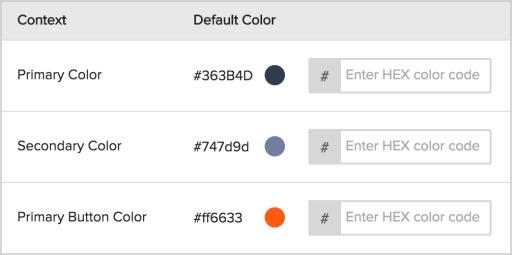

0d496c6c52afe8859012d3dbbd5169dc
Flood rescue teams are helping children and women out of floods. - 95208356


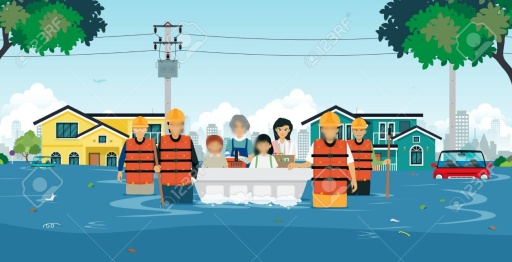

8715067b5c9dd32de920706eea217e4b
SPECIALIZED ROCKHOPPER COMP 29 CHAR/BLK/FTHYWHT XL - Alpha Bikes


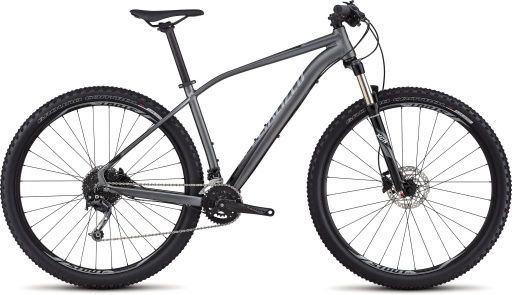

In [97]:
display_uids(uids_gt_75_perc)

## Lower than 25 percentile

Found 4 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data
08ba3b715e8743ab0cdff5f897fcddde
Isobel aurait pu être incarnée par... Neve Campbell !


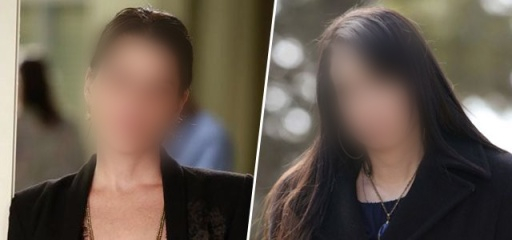

28d515244afceddc0ec70ae600d400be
Quadra recebe grama sintética, no Parque dos Pioneiros (Foto: Siga Mais).


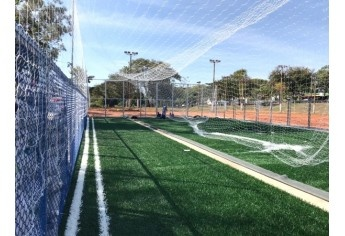

d75ea023ea898967a3ab96f46d15e370
遠距離恋愛（社会人×社会人）


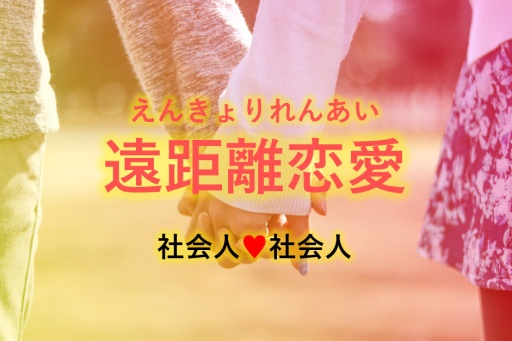

a182730f1da0dc1629a0b0f92c4cbb1a
デジタルとアナログを繋ぐMOLESKINE「スマートライティングセット」


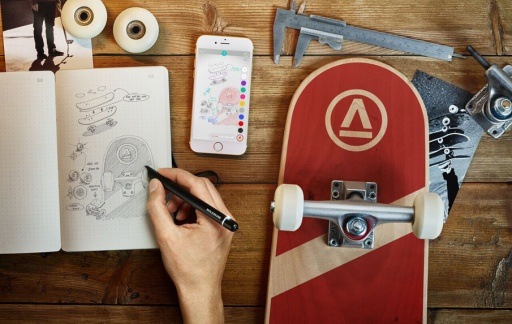

95eb969f3314a51c283f0374b5452db1
Recibidor formado por consola y doble espejo - Decoracion de recibidores y pasillos ...


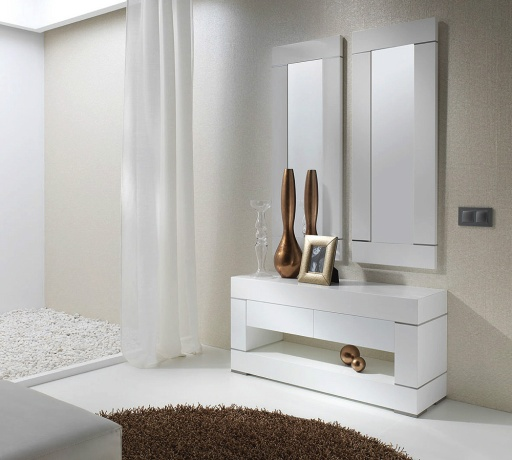

fdec35f8fede7c466a7bcbc070932f7c
AMF_KSA_Ri


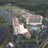

1123a49daddf43d918654da966ddfe11
春季传染病预防知识


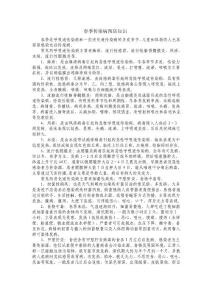

82a0a876aa4394cf5892faa3a285012d
太和山庄


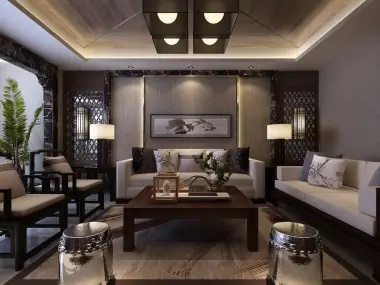

bd9a2aeebd0692067d1c8e2e8051332c
吹牛啤瓶装


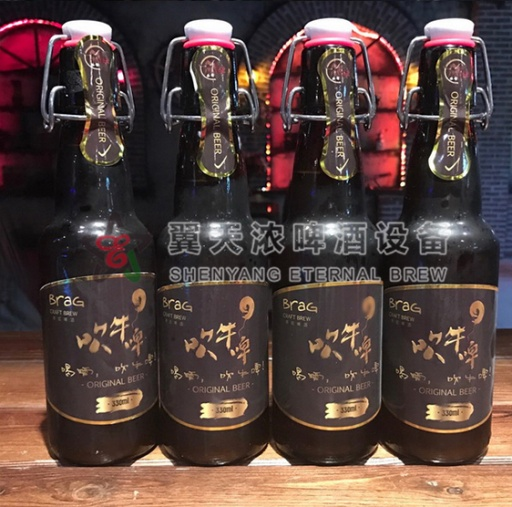

848661dc635a4fe5ad7dcc9b7788ff0c
https://bt-photos.global.ssl.fastly.net/bowlinggreen/orig_boomver_1_RA20224002-2.jpg


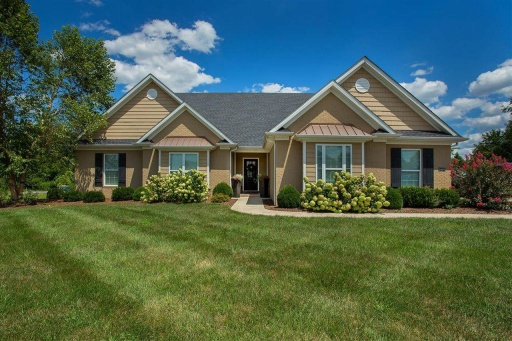

In [99]:
display_uids(uids_lt_25_perc)

## Between 25 and 75 percentile

Found 4 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data
09a535e0412d2afc37dda82b7aa45187
Sensores multifocales


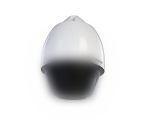

3b6796380f9af81749ab07c4e0789afa
Ốp lưng iPhone Xs Max Nillkin Flex Case Silicon mềm mịn


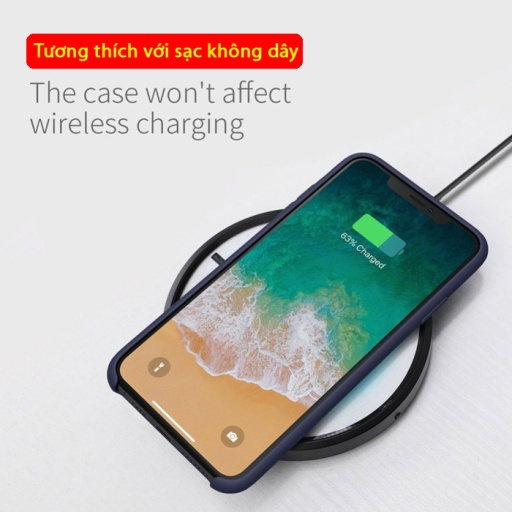

6c0b6cad17bd71d3d9eceac8118e45fd
Die Botschaft der Jungwähler an die Politik


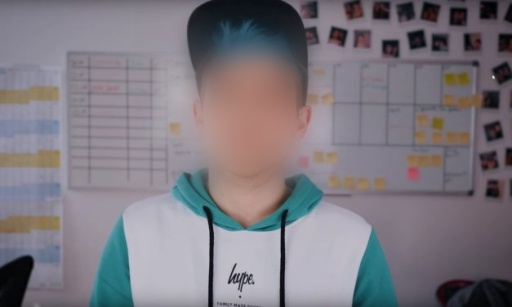

533bcb207ef7818507b7d3224e22b391
IMG_8753


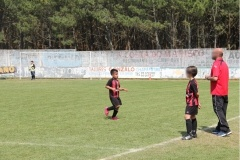

44bd561d6fa2fd8b1ebd86705d1a14c2
mouse


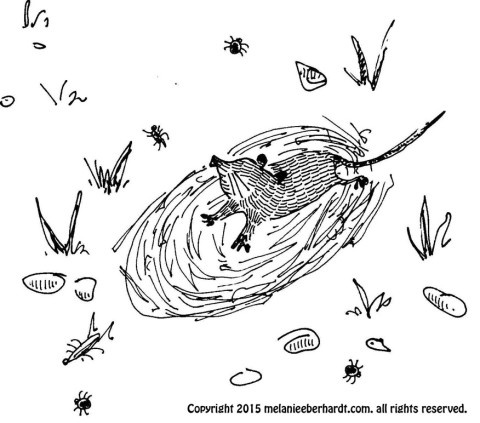

7add2f0dcf1f27c1073d1346c3903f5e
modern design furniture. Furniture Modern Design Images Best 25 Ideas On Pinterest Chair U


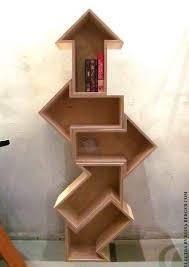

377951c86df2d8c15c8e23cf33b0af59
astroliz


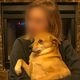

c08a0dd9cc8b2d9c016b7b893757d839
Photo de Tagoudit-Anefgou


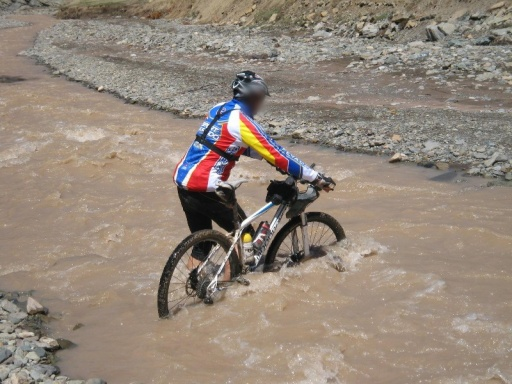

8ea10a184653ef682de7e60c0038b12a
En Brasil el etanol ya no es mejor negocio que el azúcar


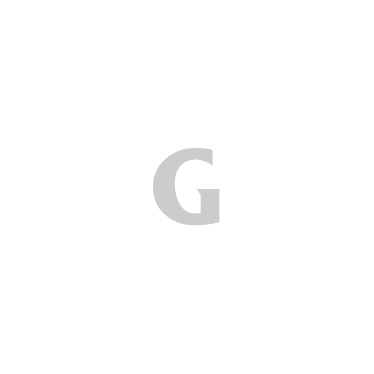

c49ff642dc20a1955dbfe4d1ae5904fa
satys.JPG


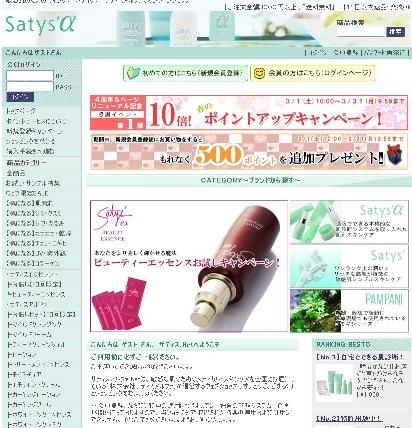

In [100]:
display_uids(uids_between_25_and_75_perc)